In [1]:
import numpy as np

- rand - matrix [100,1]
- 4 - bias
- 3 - true weight value for the X matrix
- randn - matrix [100,1] within the Gaussian distribution - like a random noise


In [2]:
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

In [3]:
import matplotlib.pyplot as plt

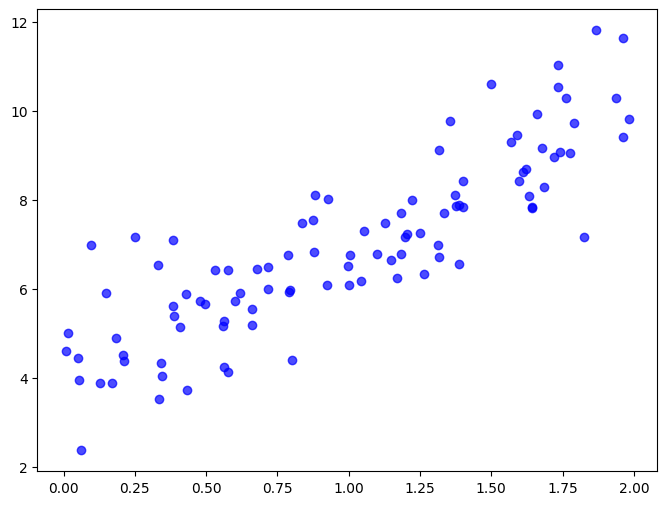

In [4]:
plt.figure(figsize=(8,6))
plt.scatter(X, y, color="blue", alpha=0.7, label="Data with noise")

- inv() - built-in inversion of matrix
- dot() - matrices multiplication

In [5]:
X_b = np.c_[np.ones((100,1)),X] # to add bias
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
theta_best

array([[4.04095921],
       [2.9617077 ]])

- np.array([[0], [2]]) - matrix [2,1]

In [6]:
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2,1)), X_new]
y_pred = X_new_b.dot(theta_best)
y_pred

array([[4.04095921],
       [9.96437461]])

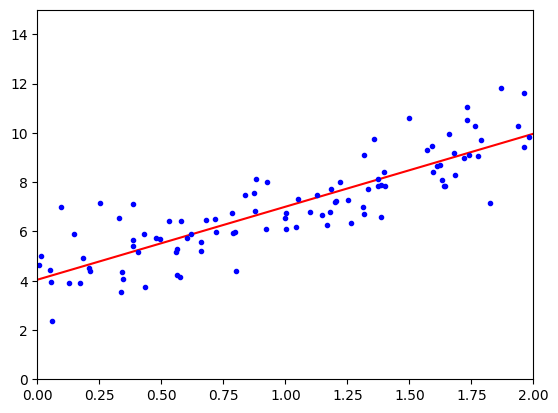

In [7]:
plt.plot(X_new, y_pred, "r-")
plt.plot(X, y, "b.")
plt.axis([0, 2, 0, 15])
plt.show()

In [8]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X,y)
print(f"{lin_reg.intercept_}, {lin_reg.coef_}")
print(lin_reg.predict(X_new))

[4.04095921], [[2.9617077]]
[[4.04095921]
 [9.96437461]]


intercept_ - bias
coef_ - weight

In [9]:
eta = 0.1
n_iterations = 1000
m = 100
theta = np.random.randn(2,1)

for iteration in range(n_iterations):
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
    theta = theta - eta * gradients

print(theta)

[[4.04095921]
 [2.9617077 ]]


In [15]:
n_epochs = 50
t0, t1 = 5, 50 #hyperparams
def learning_schedule(t):
    return t0 / (t + t1)

theta = np.random.randn(2,1)

for epoch in range(n_epochs):
    for i in range(m):
        random_index = np.random.randint(m)
        xi = X_b[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
        eta = learning_schedule(epoch * m + i)
        theta = theta - eta * gradients

theta

array([[4.07974027],
       [2.98246359]])

In [13]:
from sklearn.linear_model import SGDRegressor
sgd_reg = SGDRegressor(max_iter=1000, tol=1e-3, penalty=None, eta0=0.1) #tol -> loss, penalty=None - no regularization, eta0 - learning rate
sgd_reg.fit(X, y.ravel()) # transforming into 1D array

sgd_reg.intercept_, sgd_reg.coef_

(array([4.03144936]), array([2.98037941]))